In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

In [6]:
# Load pre-trained sentence transformer model
# This model produces 384-dimensional embeddings
model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Model loaded: {model.get_sentence_embedding_dimension()} dimensions")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded: 384 dimensions


In [41]:
# Four diverse countries
countries = [
    'United States of America',
    'Nigeria', 
    # 'Japan',
    # 'Brazil',
    # 'Germany',
    # 'India',
    # 'Australia',
    # 'South Africa',
    # 'China',
    # 'Russia',
    # 'Iceland',
    'Mexico',
    'Spain',
    # 'France',
    # 'Bhutan',
    # 'Canada',
    'Liberia',
    'New York',
    'Madrid',
    'Lagos',
    'Britain',
    'South Africa'
    # 'Palestine',
    # 'Israel'
]

# Get embeddings
embeddings = model.encode(countries)

print(f"Embeddings shape: {embeddings.shape}")
print(f"Countries: {countries}")

Embeddings shape: (10, 384)
Countries: ['United States of America', 'Nigeria', 'Mexico', 'Spain', 'Liberia', 'New York', 'Madrid', 'Lagos', 'Britain', 'South Africa']


In [42]:
# Reduce to 2D using PCA
pca = PCA(n_components=2)
coords_2d = pca.fit_transform(embeddings)

print(f"2D coordinates shape: {coords_2d.shape}")
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_):.2%}")

2D coordinates shape: (10, 2)
Explained variance ratio: [0.25114453 0.1916941 ]
Total variance explained: 44.28%


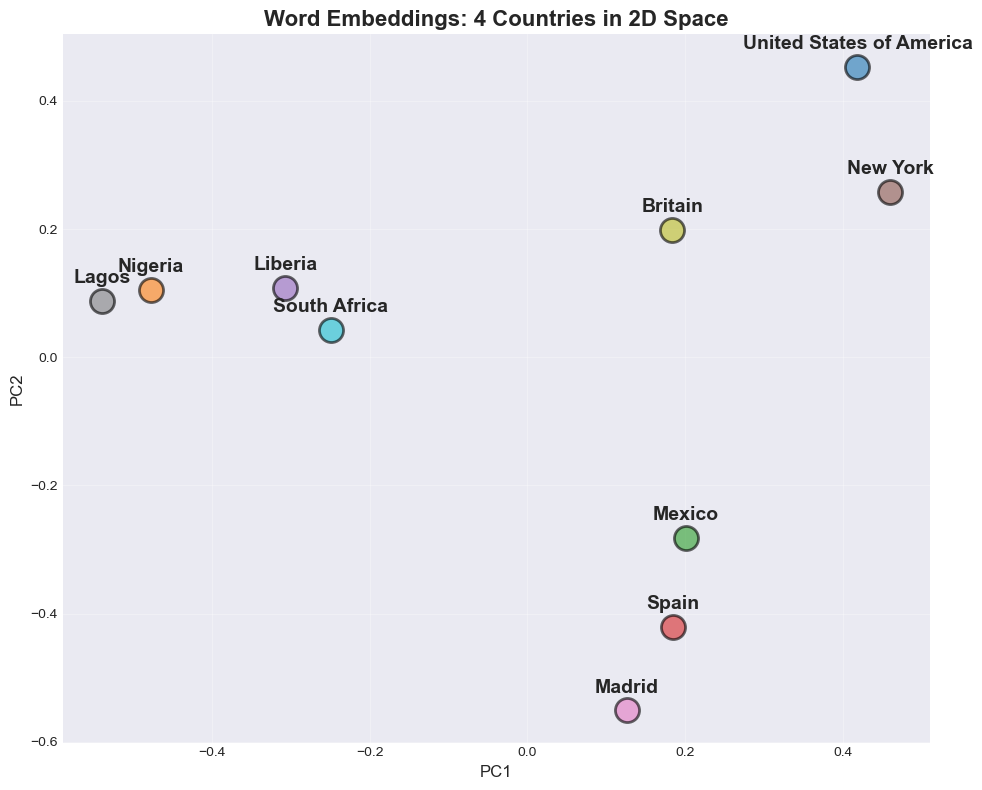

In [43]:
# Create visualization
fig, ax = plt.subplots(figsize=(10, 8))

# Plot points
# colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']
for i, country in enumerate(countries):
    ax.scatter(coords_2d[i, 0], coords_2d[i, 1], 
              s=300, alpha=0.6, edgecolors='black', linewidth=2)
    ax.annotate(country, 
               (coords_2d[i, 0], coords_2d[i, 1]),
               fontsize=14,
               fontweight='bold',
               ha='center',
               va='bottom',
               xytext=(0, 10),
               textcoords='offset points')

ax.set_xlabel('PC1', fontsize=12)
ax.set_ylabel('PC2', fontsize=12)
ax.set_title('Word Embeddings: 4 Countries in 2D Space', fontsize=16, fontweight='bold')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('countries_2d.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
# Calculate pairwise distances in embedding space
from scipy.spatial.distance import pdist, squareform

distances = squareform(pdist(embeddings, metric='cosine'))

print("\nCosine distances between countries:")
print("="*50)
for i, country1 in enumerate(countries):
    for j, country2 in enumerate(countries):
        if i < j:
            print(f"{country1} <-> {country2}: {distances[i, j]:.4f}")


Cosine distances between countries:
United States of America <-> Nigeria: 0.6149
United States of America <-> Japan: 0.5748
United States of America <-> Brazil: 0.5572
Nigeria <-> Japan: 0.4752
Nigeria <-> Brazil: 0.4462
Japan <-> Brazil: 0.3227


In [55]:
# Choose which list to visualize
selected_countries = climate_countries  # Change to economy_countries or colonization_countries
theme = "Climate"  # Change to "Economy" or "Colonization"

# Get embeddings
selected_embeddings = model.encode(selected_countries)

# Reduce to 2D
pca_theme = PCA(n_components=2)
coords_2d_theme = pca_theme.fit_transform(selected_embeddings)

print(f"Theme: {theme}")
print(f"Embeddings shape: {selected_embeddings.shape}")
print(f"Explained variance: {sum(pca_theme.explained_variance_ratio_):.2%}")

Theme: Climate
Embeddings shape: (16, 384)
Explained variance: 34.20%


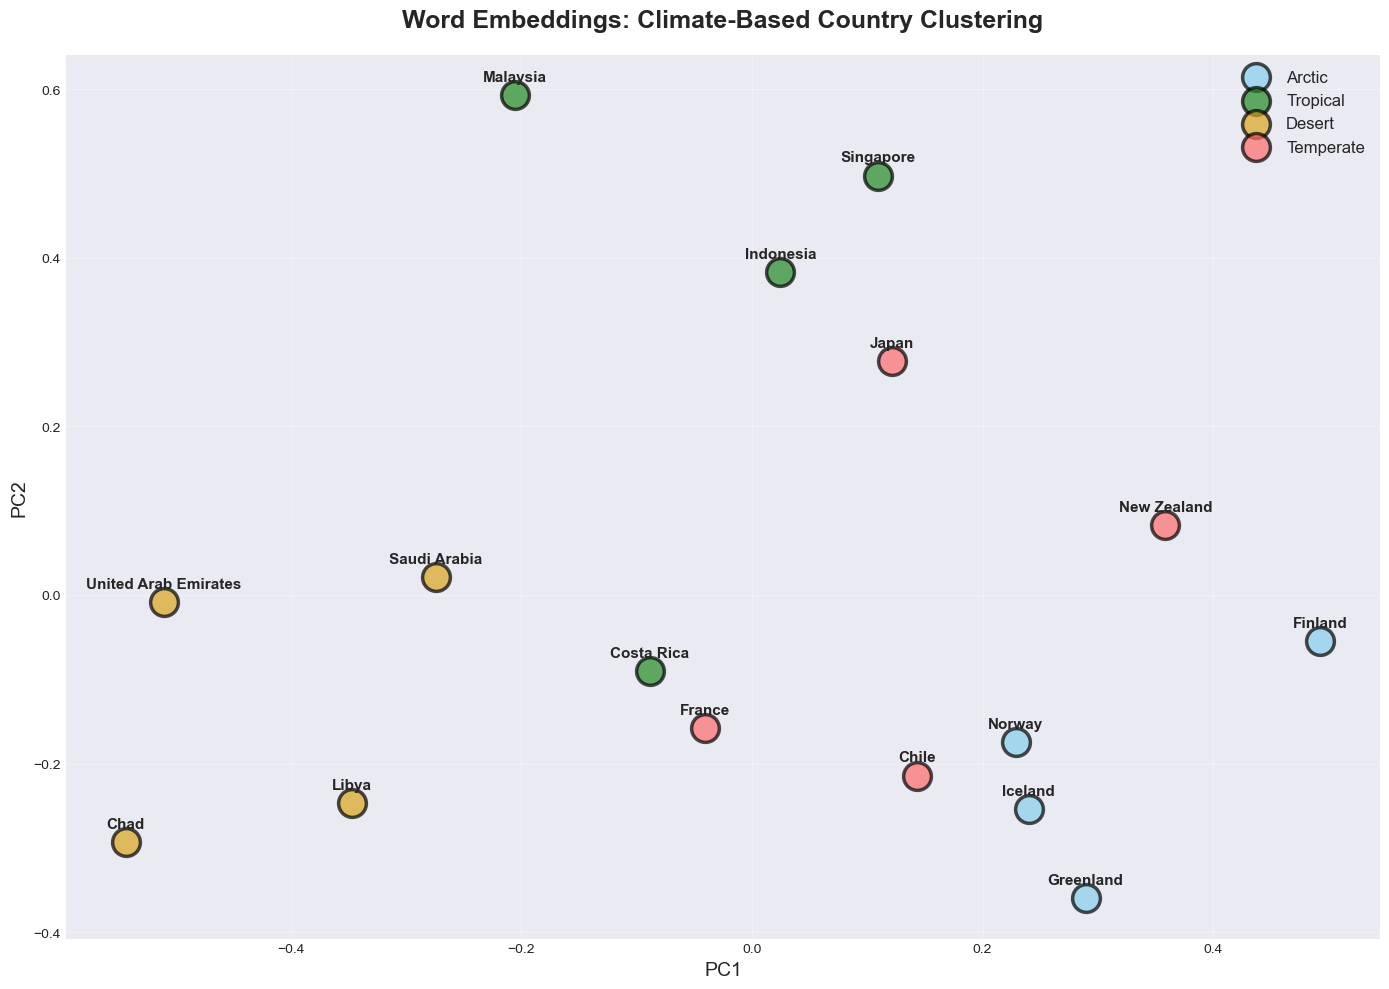

In [56]:
# Visualize thematic grouping
fig, ax = plt.subplots(figsize=(14, 10))

# Define colors for each category (4 categories per theme)

if theme == "Climate":
    categories = {
        'Arctic': ['Iceland', 'Norway', 'Greenland', 'Finland'],
        'Tropical': ['Singapore', 'Indonesia', 'Costa Rica', 'Malaysia'],
        'Desert': ['Saudi Arabia', 'Libya', 'Chad', 'United Arab Emirates'],
        'Temperate': ['France', 'Japan', 'New Zealand', 'Chile']
    }
    colors_map = {'Arctic': '#87CEEB', 'Tropical': '#228B22', 'Desert': '#DAA520', 'Temperate': '#FF6B6B'}
elif theme == "Economy":
    categories = {
        'Developed': ['Germany', 'Switzerland', 'United States', 'South Korea'],
        'Emerging': ['Brazil', 'India', 'China', 'South Africa'],
        'Developing': ['Haiti', 'Nepal', 'Ethiopia', 'Bangladesh'],
        'Oil-Rich': ['Qatar', 'Kuwait', 'Saudi Arabia', 'Bahrain']
    }
    colors_map = {'Developed': '#4169E1', 'Emerging': '#FFD700', 'Developing': '#DC143C', 'Oil-Rich': '#2F4F4F'}
elif theme == "Colonization":
    categories = {
        'British': ['India', 'Nigeria', 'Australia', 'Jamaica'],
        'French': ['Algeria', 'Senegal', 'Vietnam', 'Haiti'],
        'Spanish': ['Mexico', 'Peru', 'Philippines', 'Argentina'],
        'Portuguese': ['Brazil', 'Angola', 'Mozambique', 'East Timor']
    }
    colors_map = {'British': '#C8102E', 'French': '#0055A4', 'Spanish': '#FFC400', 'Portuguese': '#006847'}

# Plot points with category colors
for i, country in enumerate(selected_countries):
    # Find category for this country
    category = None
    for cat, countries_list in categories.items():
        if country in countries_list:
            category = cat
            break
    
    color = colors_map[category] if category else '#808080'
    ax.scatter(coords_2d_theme[i, 0], coords_2d_theme[i, 1], 
              s=400, c=color, alpha=0.7, edgecolors='black', linewidth=2.5,
              label=category if country == categories[category][0] else "")
    ax.annotate(country, 
               (coords_2d_theme[i, 0], coords_2d_theme[i, 1]),
               fontsize=11,
               fontweight='bold',
               ha='center',
               va='bottom',
               xytext=(0, 8),
               textcoords='offset points')

# Add legend
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), loc='best', fontsize=12, framealpha=0.9)

ax.set_xlabel('PC1', fontsize=14)
ax.set_ylabel('PC2', fontsize=14)
ax.set_title(f'Word Embeddings: {theme}-Based Country Clustering', fontsize=18, fontweight='bold', pad=20)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'countries_2d_{theme.lower()}.png', dpi=300, bbox_inches='tight')
plt.show()

In [48]:
# COLONIZATION-BASED GROUPING
# Expected clusters: British, French, Spanish, Portuguese colonial histories

colonization_countries = [
    # Former British Colonies
    'India',
    'Nigeria',
    'Australia',
    'Jamaica',
    
    # Former French Colonies
    'Algeria',
    'Senegal',
    'Vietnam',
    'Haiti',
    
    # Former Spanish Colonies
    'Mexico',
    'Peru',
    'Philippines',
    'Argentina',
    
    # Former Portuguese Colonies
    'Brazil',
    'Angola',
    'Mozambique',
    'East Timor'
]

In [47]:
# ECONOMY-BASED GROUPING
# Expected clusters: Developed, Emerging, Developing, Oil-rich

economy_countries = [
    # Developed/Advanced
    'Germany',
    'Switzerland',
    'United States',
    'South Korea',
    
    # Emerging Markets (BRICS-like)
    'Brazil',
    'India',
    'China',
    'South Africa',
    
    # Developing/Low Income
    'Haiti',
    'Nepal',
    'Ethiopia',
    'Bangladesh',
    
    # Oil-Rich Gulf States
    'Qatar',
    'Kuwait',
    'Saudi Arabia',
    'Bahrain'
]

In [46]:
# CLIMATE-BASED GROUPING
# Expected clusters: Arctic, Tropical, Desert, Temperate

climate_countries = [
    # Arctic/Cold
    'Iceland',
    'Norway', 
    'Greenland',
    'Finland',
    
    # Tropical
    'Singapore',
    'Indonesia',
    'Costa Rica',
    'Malaysia',
    
    # Desert
    'Saudi Arabia',
    'Libya',
    'Chad',
    'United Arab Emirates',
    
    # Temperate
    'France',
    'Japan',
    'New Zealand',
    'Chile'
]

---

## Thematic Country Lists

Different groupings designed to produce clear clusters based on:
- **Climate**: Arctic, tropical, desert, temperate zones
- **Economy**: Developed, developing, emerging markets
- **Colonization**: British, French, Spanish colonial history